### per trial pearson correlation 

##### eye tracking data with marked movie segments

In [ ]:
#this is script for doing 1.5 sec around matching timestamp but i started modifying it for full segment (but i should change it to previous verison so 1.5)
import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# --- Adjust here ---
pilot_0X = "pilot_05"        # participant 1
pilot_0Y = "pilot_06"        # participant 2
movie = "sprout"             # merged movie name

# How many rows to use from each segment (None = use all)
max_rows_per_segment = 180

# Segments to reject
reject_segments = ["seg_26", "seg_33"]  # segments that I want to reject, sprout: seg_26 "seg_33"
# -------------------

# Paths (merged eye data and movie segments)
dir = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/eye_data_with_matching_segments/"   # for 1.5 sec around matching frame"/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/eye_data_with_matching_segments/"
dir_out = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participants_3sec"

eye_data_0X = pd.read_csv(os.path.join(dir, f"{movie}_{pilot_0X}_merged_eye_data_with_movie_segments.csv")) #FULL_segments
eye_data_0Y = pd.read_csv(os.path.join(dir, f"{movie}_{pilot_0Y}_merged_eye_data_with_movie_segments.csv")) #_FULL_segments

# Helper functions
def combine_x_then_y(x, y):
    """Combine x and y arrays vertically: all x values followed by all y values."""
    return np.concatenate((x, y))

def compute_correlation(vec1, vec2):
    """Compute Pearson correlation between two combined x+y vectors."""
    return pearsonr(vec1, vec2)

# Get common segments
segments = sorted(set(eye_data_0X["segment_id"].dropna()) & set(eye_data_0Y["segment_id"].dropna()))
segments = [s for s in segments if s not in reject_segments]

results = []

for seg in segments:
    seg_data_0X = eye_data_0X[eye_data_0X["segment_id"] == seg]
    seg_data_0Y = eye_data_0Y[eye_data_0Y["segment_id"] == seg]

    # Ensure equal length
    min_len = min(len(seg_data_0X), len(seg_data_0Y))
    if max_rows_per_segment is not None:
        min_len = min(min_len, max_rows_per_segment)

    if min_len < 2:
        continue  # skip too-short segments

    x1, y1 = seg_data_0X["x"].values[:min_len], seg_data_0X["y"].values[:min_len]
    x2, y2 = seg_data_0Y["x"].values[:min_len], seg_data_0Y["y"].values[:min_len]

    vec1 = combine_x_then_y(x1, y1)
    vec2 = combine_x_then_y(x2, y2)

    corr_coef, p_value = compute_correlation(vec1, vec2)

    results.append({
        "segment_id": seg,
        "participant_X": pilot_0X,
        "participant_Y": pilot_0Y,
        "rows_used": min_len,
        "r": corr_coef,
        "p": p_value
    })

# Collect results into DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Save output
output_path = os.path.join(dir_out, f"{movie}_correlation_{pilot_0X}_{pilot_0Y}.csv")
results_df.to_csv(output_path, index=False)
print(f"Saved results to {output_path}")


   segment_id participant_X participant_Y  rows_used         r             p
0       seg_1      pilot_05      pilot_06        180  0.469568  3.841899e-21
1      seg_10      pilot_05      pilot_06        180 -0.350514  7.604877e-12
2      seg_11      pilot_05      pilot_06        180 -0.248380  1.830739e-06
3      seg_12      pilot_05      pilot_06        180  0.363988  1.017263e-12
4      seg_13      pilot_05      pilot_06        180  0.171823  1.063544e-03
5      seg_14      pilot_05      pilot_06        180 -0.085519  1.052443e-01
6      seg_15      pilot_05      pilot_06        180  0.402568  1.857274e-15
7      seg_16      pilot_05      pilot_06        180  0.266591  2.839221e-07
8      seg_17      pilot_05      pilot_06        180  0.060478  2.523978e-01
9      seg_18      pilot_05      pilot_06        180  0.335970  6.005779e-11
10     seg_19      pilot_05      pilot_06        180  0.415984  1.696375e-16
11      seg_2      pilot_05      pilot_06        180  0.206983  7.605944e-05

#### getting pearson pairwise correlation between all subjects for each movie

##### I input files that have eye tracking data (both movie parts) merged with movie segments (segment_id)

In [24]:
import os
import itertools
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def pearson_corr_per_segment(
    movie_name: str,
    participants: list,
    base_dir="/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/eye_data_with_matching_segments/",
    save_dir="/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all",
    max_rows_per_segment=None,
    reject_segments=None
):
    """
    Compute Pearson correlations between all participant pairs for the same movie,
    using pre-defined segment IDs in the input files.

    Parameters
    ----------
    movie_name : str
        Name of the movie (e.g., 'prayer', 'sprout').
    participants : list of str
        List of participant IDs (e.g., ['pilot_03', 'pilot_05', 'pilot_07']).
    base_dir : str
        Directory containing merged eye tracking data with movie segments. 
    save_dir : str
        Directory where pairwise pearson correlation for each segment will be saved.
    max_rows_per_segment : int or None
        Optionally limit number of rows per segment for performance (default: None).
    reject_segments : list of str or None
        List of segment IDs to skip during processing (e.g., ['5', '7', '12']).
    """

    def combine_x_then_y(x, y):
        return np.concatenate((x, y))

    def compute_correlation(vec1, vec2):
        return pearsonr(vec1, vec2)

    os.makedirs(save_dir, exist_ok=True)

    # Load data for each participant
    movie_path = os.path.join(base_dir)
    data_dict = {}
    for p in participants:
        file_path = os.path.join(movie_path, f"{movie_name}_{p}_merged_eye_data_with_movie_segments.csv")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file for {movie_name}: {p}")
            continue

        df = pd.read_csv(file_path)
        if "segment_id" not in df.columns:
            raise KeyError(f"Missing 'segment_id' column in {file_path}")

        df["segment_id"] = df["segment_id"].astype(str)
        data_dict[p] = df

    # Participant pairs
    pairs = list(itertools.combinations(participants, 2))

    for p1, p2 in pairs:
        if p1 not in data_dict or p2 not in data_dict:
            continue

        df1, df2 = data_dict[p1], data_dict[p2]
        segments = sorted(set(df1["segment_id"]).intersection(df2["segment_id"]))

        results = []

        for seg in segments:
            # Skip unwanted segments
            if reject_segments is not None and seg in reject_segments:
                print(f"⏭️ Rejecting segment {seg} for pair {p1}-{p2}")
                continue

            seg_data_1 = df1[df1["segment_id"] == seg]
            seg_data_2 = df2[df2["segment_id"] == seg]

            min_len = min(len(seg_data_1), len(seg_data_2))
            if max_rows_per_segment is not None:
                min_len = min(min_len, max_rows_per_segment)

            if min_len < 2:
                continue

            x1, y1 = seg_data_1["x"].values[:min_len], seg_data_1["y"].values[:min_len]
            x2, y2 = seg_data_2["x"].values[:min_len], seg_data_2["y"].values[:min_len]

            vec1 = combine_x_then_y(x1, y1)
            vec2 = combine_x_then_y(x2, y2)

            try:
                r, p_val = compute_correlation(vec1, vec2)
            except Exception:
                r, p_val = np.nan, np.nan

            results.append({
                "segment_id": seg,
                "participant_X": p1,
                "participant_Y": p2,
                "rows_used": min_len,
                "r": r,
                "p": p_val
            })

        # Save results
        out_df = pd.DataFrame(results)
        out_path = os.path.join(save_dir, f"{movie_name}_correlation_{p1}_{p2}.csv")
        out_df.to_csv(out_path, index=False)
        print(f"✅ Saved: {out_path}")


In [28]:
#applying the function

pearson_corr_per_segment(
    movie_name="sprout",
    participants=["pilot_07", "pilot_09", "pilot_10", "pilot_11", "pilot_12","pilot_14" ,"pilot_15","pilot_16" ,"pilot_17", "pilot_18", "pilot_19", "pilot_20", "pilot_21",
                   "pilot_22", "pilot_23", "pilot_24","pilot_25" ,"pilot_26", "pilot_27" ,"pilot_28", "pilot_29", "pilot_30", "pilot_31", "pilot_32", "pilot_33", "pilot_34", "pilot_35", "pilot_36", "pilot_37", "pilot_38"], 
                  reject_segments = ["seg_26"]
    
)
#"pilot_14", reject_segments=["seg_26"] "pilot_16", "pilot_15", 

#from "guest" exclude pilot 15
#from prayer exclude: pilot_14   #and prayer reject segment: seg_22
# from witness exclude: pilot_16
# sprout reject segments: seg_26




⏭️ Rejecting segment seg_26 for pair pilot_07-pilot_09
✅ Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all/sprout_correlation_pilot_07_pilot_09.csv
⏭️ Rejecting segment seg_26 for pair pilot_07-pilot_10
✅ Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all/sprout_correlation_pilot_07_pilot_10.csv
⏭️ Rejecting segment seg_26 for pair pilot_07-pilot_11
✅ Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all/sprout_correlation_pilot_07_pilot_11.csv
⏭️ Rejecting segment seg_26 for pair pilot_07-pilot_12
✅ Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all/sprout_correlation_pilot_07_pilot_12.csv
⏭️ Rejecting segment seg_26 for pair pilot_07-pilot_14
✅ Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_a

## Deriving two synchrony metrics: individual-to-group synchorny (IGS) and group-synchrony (GS) from eye tracking data.
#### input files are the pearson pairwise correlation values that is obtained for each movie segment (each 3sec)
#### getting group average (GS values) with the leave one out method

In [ ]:
#this is the updated version, and the current version that I use. I modified how I was obtaining group synchrony. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

def compute_group_and_pilot_sync(
    movie: str,
    participants: list,
    data_dir: str = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/pear_corr/participant_3sec_all",
    output_dir_base: str = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/saving_synchrony",
    specific: str = "3sec",
    reject_segments: list = None,   # new argument
    plot: bool = True
):
    """
    Compute group average (leave-one-out) and pilot mean synchrony per segment,
    with an option to reject specific segments before averaging.

    Parameters
    ----------
    movie : str
        Movie name (e.g. 'witness', 'sprout', etc.)
    participants : list of str
        Participant IDs to include (e.g. ['pilot_07', 'pilot_08', ...])
    reject_segments : list of int, optional
        Segment numbers to exclude from synchrony computation.
    """

    pattern = os.path.join(data_dir, f"{movie}_correlation_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched {pattern}")

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=None, engine="python").rename(columns=str.strip)
        needed = {"segment_id", "participant_X", "participant_Y", "r"}
        missing = needed - set(df.columns)
        if missing:
            raise ValueError(f"{os.path.basename(f)} missing columns: {missing}")

        df["segment_id"] = df["segment_id"].astype(str)
        df["segment_num"] = (
            df["segment_id"].str.extract(r"(\d+)", expand=False)
            .astype(float)
            .astype("Int64")
        )
        df = df.dropna(subset=["segment_num"])
        df["segment_num"] = df["segment_num"].astype(int)
        dfs.append(df[["segment_id", "segment_num", "participant_X", "participant_Y", "r"]])

    pairs = pd.concat(dfs, ignore_index=True)
    pairs["r"] = pd.to_numeric(pairs["r"], errors="coerce")
    pairs = pairs.dropna(subset=["r", "segment_num"]).reset_index(drop=True)

    # --- Reject unwanted segments ---
    if reject_segments:
        before_n = pairs["segment_num"].nunique()
        pairs = pairs[~pairs["segment_num"].isin(reject_segments)]
        after_n = pairs["segment_num"].nunique()
        print(f"🗑 Rejected {before_n - after_n} segments: {reject_segments}")

    # --- Only keep pairs that include the specified participants ---
    pairs = pairs[pairs["participant_X"].isin(participants) & pairs["participant_Y"].isin(participants)]
    if pairs.empty:
        raise ValueError("No matching pairs found for the given participants.")

    # --- Pilot-level long format ---
    left = pairs[["segment_num", "participant_X", "r"]].rename(columns={"participant_X": "participant"})
    right = pairs[["segment_num", "participant_Y", "r"]].rename(columns={"participant_Y": "participant"})
    pilot_long = pd.concat([left, right], ignore_index=True)

    # --- Compute pilot mean per segment ---
    pilot_avg = (
        pilot_long.groupby(["segment_num", "participant"], as_index=False)["r"]
        .mean()
        .rename(columns={"r": "pilot_mean"})
    )
# --- Compute leave-one-out group mean per segment ---
    group_avg = []
    for seg, seg_pairs in pairs.groupby("segment_num"):
        for p in participants:
            mask = (
                (seg_pairs["participant_X"] != p) &
                (seg_pairs["participant_Y"] != p)
            )
            vals = seg_pairs.loc[mask, "r"]
            group_avg.append({
                "segment_num": seg,
                "participant": p,
                "group_mean": vals.mean() if len(vals) else np.nan
            })

    group_avg = pd.DataFrame(group_avg)


    # --- Merge results ---
    results = pilot_avg.merge(group_avg, on=["segment_num", "participant"], how="left")

    # --- Save results ---
    #output_dir = os.path.join(output_dir_base, movie)
    #os.makedirs(output_dir, exist_ok=True)
    #output_path = os.path.join(output_dir, f"participants_sync_metrics_{movie}_{specific}_final_30_subjects.csv")
    #results.to_csv(output_path, index=False)
    #print(f"✅ Saved synchrony metrics to: {output_path}")

    # --- Plot (optional) ---
    TITLE_SIZE = 30
    LABEL_SIZE = 25
    TICK_SIZE = 20
    LEGEND_SIZE = 20


    if plot:
        seg_order = np.sort(pairs["segment_num"].unique())
        fig, ax_left = plt.subplots(figsize=(12, 6))

        # Plot pilot mean
        for participant, sub in results.sort_values("segment_num").groupby("participant"):
            ax_left.plot(
                sub["segment_num"],
                sub["pilot_mean"],
                marker="o",
                linestyle="--",
                alpha=0.8,
                #label=f"{participant} (mean)"
            )

        # Group mean
        ax_right = ax_left.twinx()
        ga_sorted = results.groupby("segment_num", as_index=False)["group_mean"].mean()
        ax_right.plot(
            ga_sorted["segment_num"],
            ga_sorted["group_mean"],
            marker="s",
            linestyle="-",
            linewidth=3.5,
            color="black",
            label="Group mean (leave-one-out)"
        )

        ax_left.set_xlabel("Trial", fontsize=LABEL_SIZE)
        ax_left.set_ylabel("Synchrony (r)", fontsize=LABEL_SIZE)
        

        ax_left.grid(True, linestyle="--", alpha=0.6)
            #ax.left an right control number on the axes
        ax_left.tick_params(axis="both", labelsize=TICK_SIZE)
        ax_right.tick_params(axis="y", labelsize=TICK_SIZE)


        #h_left, l_left = ax_left.get_legend_handles_labels()
        #h_right, l_right = ax_right.get_legend_handles_labels()
        #ax_left.legend(h_left + h_right, l_left + l_right, bbox_to_anchor=(1.04, 1), loc="upper left"))

        plt.title(f"Inidividual vs. group synchrony per trial for {movie} movie", fontsize=TITLE_SIZE)
        plt.tight_layout()
        plt.show()

    return results


🗑 Rejected 0 segments: ['seg_26']
✅ Saved synchrony metrics to: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/saving_synchrony/sprout/participants_sync_metrics_sprout_3sec_final_30_subjects.csv


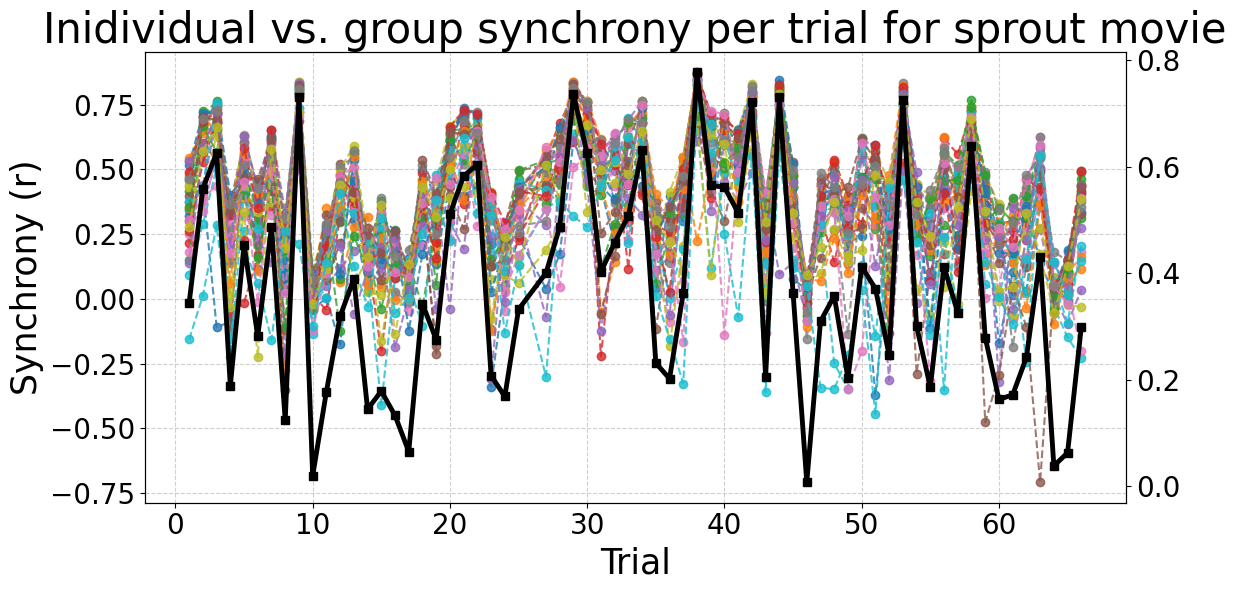

In [41]:
results = compute_group_and_pilot_sync(
    movie="sprout",
    participants = ["pilot_07", "pilot_09", "pilot_10", "pilot_11", "pilot_12","pilot_14", "pilot_15", "pilot_16", "pilot_17", "pilot_18", "pilot_19", "pilot_20", "pilot_21",
                    "pilot_22", "pilot_23", "pilot_24","pilot_25" ,"pilot_26", "pilot_27" ,"pilot_28", "pilot_29", "pilot_30", "pilot_31", "pilot_32", "pilot_33", "pilot_34", "pilot_35", "pilot_36", "pilot_37", "pilot_38"],
    specific="3sec",
    reject_segments=["seg_26"]

)


#from "guest" exclude pilot 15
#from prayer exclude: pilot_14   #and prayer reject segment: seg_22
# from witness exclude: pilot_16
# sprout reject segments: seg_26

In [ ]:
## script for showing individual synchrony and group synchrony values

plt.rcParams.update({"font.size": 14}) #one line that sets all font to be the same in size for all figures


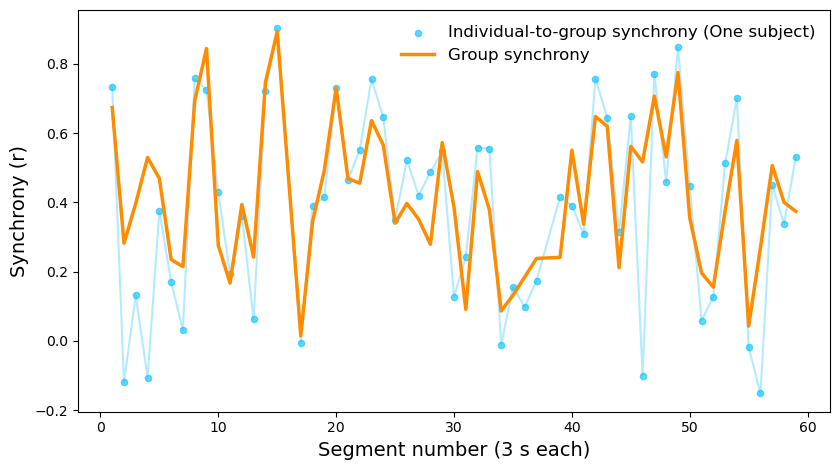

Figure saved to:
/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/saving_synchrony/witness/witness_synchrony_example.png


In [59]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
FILE_PATH = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/pear_corr_per_trial/saving_synchrony/witness/participants_sync_metrics_witness_3sec_final_30_subjects.csv"
PARTICIPANT = "pilot_10"   # <-- choose one subject here
OUT_NAME = "witness_synchrony_example.png"
#TITLE = "Witness movie: synchrony example"

# =========================
# LOAD DATA
# =========================
try:
    df = pd.read_csv(FILE_PATH, sep=None, engine="python")
except Exception:
    df = pd.read_csv(FILE_PATH, sep="\t")

required_cols = {"segment_num", "participant", "pilot_mean", "group_mean"}
assert required_cols.issubset(df.columns), f"Missing columns: {required_cols - set(df.columns)}"

df["segment_num"] = pd.to_numeric(df["segment_num"])
df["pilot_mean"] = pd.to_numeric(df["pilot_mean"])
df["group_mean"] = pd.to_numeric(df["group_mean"])

# =========================
# SELECT DATA
# =========================
df_participant = df[df["participant"] == PARTICIPANT].sort_values("segment_num")
if df_participant.empty:
    raise ValueError(f"No data found for participant {PARTICIPANT}")

# group_mean is identical across participants → keep one per trial
df_group = (
    df[["segment_num", "group_mean"]]
    .drop_duplicates("segment_num")
    .sort_values("segment_num")
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8.5, 4.8))

# Individual-to-group synchrony (grey cloud)
plt.scatter(
    df_participant["segment_num"],
    df_participant["pilot_mean"],
    color="deepskyblue",
    alpha=0.6,
    s=20,
    label=f"Individual-to-group synchrony (One subject)"
)
plt.plot(
    df_participant["segment_num"],
    df_participant["pilot_mean"],
    color="deepskyblue",
    alpha=0.3,
    linewidth=1.5
)

# Group synchrony (black)
plt.plot(
    df_group["segment_num"],
    df_group["group_mean"],
    color="darkorange",
    linewidth=2.5,

    label="Group synchrony"
)

plt.xlabel("Segment number (3 s each)", fontsize=14)
plt.ylabel("Synchrony (r)", fontsize=14)
#plt.title(TITLE)
plt.legend(frameon=False, loc="upper right", fontsize=12)

plt.tight_layout()

# =========================
# SAVE
# =========================
out_path = os.path.join(os.path.dirname(FILE_PATH), OUT_NAME)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Figure saved to:\n{out_path}")


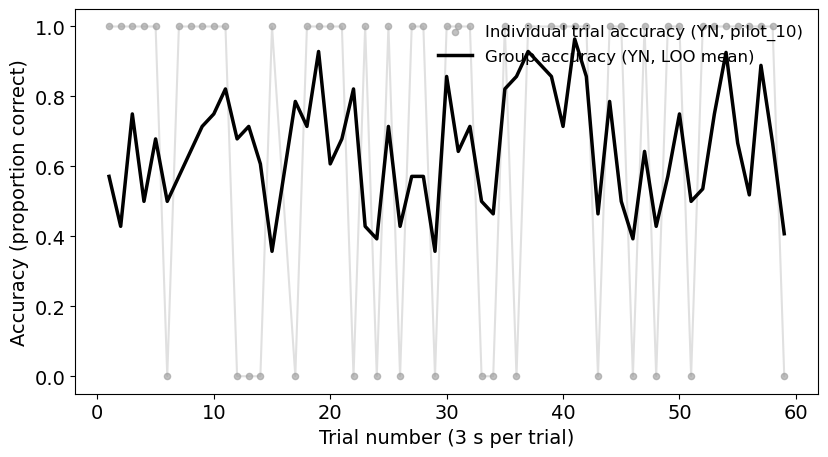

YN figure saved to:
/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/witness_accuracy_YN_pilot10.png



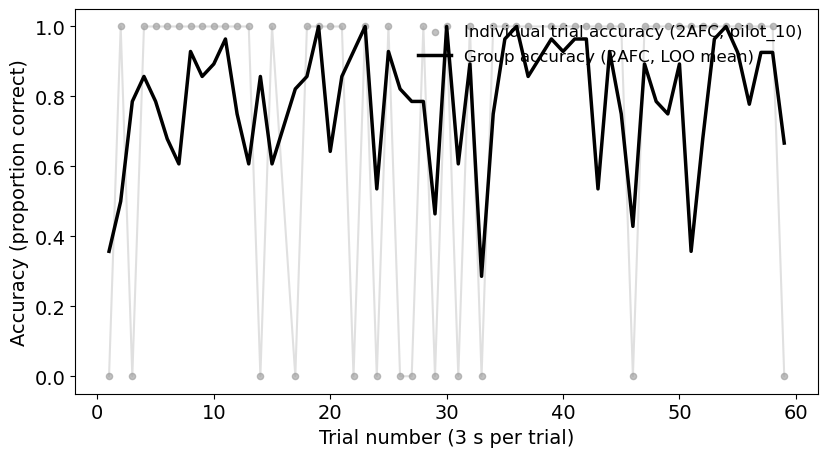

2AFC figure saved to:
/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/witness_accuracy_2AFC_pilot10.png



In [91]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
FILE_PATH = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
MOVIE = "witness"
PARTICIPANT_ID = 10          # pilot_10
OUT_NAME_YN = "witness_accuracy_YN_pilot10.png"
OUT_NAME_AFC = "witness_accuracy_2AFC_pilot10.png"

# =========================
# LOAD DATA
# =========================
try:
    df = pd.read_csv(FILE_PATH, sep=None, engine="python")
except Exception:
    df = pd.read_csv(FILE_PATH, sep="\t")

required_cols = {
    "movie", "segment_num", "participant_id",
    "correct_response_occlusion", "mean_correct_YN_LOO",
    "correct_response", "mean_correct_2AFC_LOO"
}
missing = required_cols - set(df.columns)
assert not missing, f"Missing columns: {missing}"

# Ensure numeric
df["segment_num"] = pd.to_numeric(df["segment_num"], errors="coerce")
df["participant_id"] = pd.to_numeric(df["participant_id"], errors="coerce")
df["correct_response_occlusion"] = pd.to_numeric(df["correct_response_occlusion"], errors="coerce")
df["mean_correct_YN_LOO"] = pd.to_numeric(df["mean_correct_YN_LOO"], errors="coerce")
df["correct_response"] = pd.to_numeric(df["correct_response"], errors="coerce")
df["mean_correct_2AFC_LOO"] = pd.to_numeric(df["mean_correct_2AFC_LOO"], errors="coerce")

# =========================
# SELECT DATA (one movie, one participant)
# =========================
df_movie = df[df["movie"] == MOVIE].copy()

df_participant = (
    df_movie[df_movie["participant_id"] == PARTICIPANT_ID]
    .sort_values("segment_num")
)

if df_participant.empty:
    raise ValueError(f"No data found for participant_id={PARTICIPANT_ID} in movie='{MOVIE}'")

# =========================
# PLOTTING FUNCTION (keeps same aesthetics)
# =========================
def plot_task(task_name, indiv_col, group_col, out_name):
    # group metric is identical across participants per segment -> keep one row per trial
    df_group = (
        df_movie[["segment_num", group_col]]
        .drop_duplicates("segment_num")
        .sort_values("segment_num")
        .copy()
    )

    # Convert group % to proportion (0-1) to match individual 0/1
    df_group["group_prop"] = df_group[group_col] / 100.0

    plt.figure(figsize=(8.5, 4.8))

    # Individual (grey cloud)
    plt.scatter(
        df_participant["segment_num"],
        df_participant[indiv_col],
        color="0.6",
        alpha=0.6,
        s=20,
        label=f"Individual trial accuracy ({task_name}, pilot_{PARTICIPANT_ID:02d})"
    )
    plt.plot(
        df_participant["segment_num"],
        df_participant[indiv_col],
        color="0.6",
        alpha=0.3,
        linewidth=1.5
    )

    # Group (black line)
    plt.plot(
        df_group["segment_num"],
        df_group["group_prop"],
        color="black",
        linewidth=2.5,
        label=f"Group accuracy ({task_name}, LOO mean)"
    )

    plt.xlabel("Trial number (3 s per trial)")
    plt.ylabel("Accuracy (proportion correct)")
    plt.ylim(-0.05, 1.05)
    plt.legend(frameon=False, loc="upper right", fontsize=12)
    plt.tight_layout()

    out_path = os.path.join(os.path.dirname(FILE_PATH), out_name)
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"{task_name} figure saved to:\n{out_path}\n")

# =========================
# MAKE BOTH PLOTS
# =========================
plot_task(
    task_name="YN",
    indiv_col="correct_response_occlusion",
    group_col="mean_correct_YN_LOO",
    out_name=OUT_NAME_YN
)

plot_task(
    task_name="2AFC",
    indiv_col="correct_response",
    group_col="mean_correct_2AFC_LOO",
    out_name=OUT_NAME_AFC
)


In [ ]:
# average marginal effects 

In [11]:
%load_ext rpy2.ipython

In [7]:
import pandas as pd

df = pd.read_csv(
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)
df.head()


,participant_id,segment_num,pilot_mean,group_mean,correct_response_occlusion,correct_response,response_occlusion,final_choice,target_on_left,occluded_image,...,movie,sum_correct_2AFC,sum_correct_YN,n_participants,mean_correct_2AFC_LOO,mean_correct_YN_LOO,signal_present,sum_hits_SP,n_participants_SP,mean_correct_YN_LOO_signal_present
0,7,1,0.320988,0.345468,0,1,no_response,left,True,left,...,sprout,24,19,30,79.310345,65.517241,NaN,13.0,13,NaN
1,7,2,0.432613,0.567754,1,1,left,left,True,right,...,sprout,30,26,30,100.000000,86.206897,1.0,12.0,13,91.666667
2,7,3,-0.107644,0.678453,1,1,left,right,False,left,...,sprout,27,23,30,89.655172,75.862069,1.0,10.0,13,75.000000
3,7,4,-0.089511,0.208065,1,1,left,left,True,right,...,sprout,30,26,30,100.000000,86.206897,1.0,15.0,17,87.500000
4,7,5,0.535462,0.447035,1,1,right,right,False,right,...,sprout,29,23,30,96.551724,75.862069,NaN,13.0,17,NaN


In [ ]:
#getting 2AFC marginal effects after running GLMM (after decomposition)

In [8]:
%%R -i df
library(lme4)
library(marginaleffects)

# ----------------------------
# Create decomposition predictors
# ----------------------------
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))

df$Z1 <- (df$pilot_z + df$group_z) / 2   # shared synchrony
df$Z2 <- (df$pilot_z - df$group_z) / 2   # individual deviation from group

# ----------------------------
# Fit GLMM (2AFC)
# ----------------------------
glmm_decomp_2afc <- glmer(
  correct_response ~
    Z1 +
    Z2 +
    mean_correct_2AFC_LOO +
    (1 | participant_id),
  data = df,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

summary(glmm_decomp_2afc)

# ----------------------------
# Average Marginal Effects (probability scale)
# ----------------------------
# type="response" => effects in ΔP (change in predicted probability)
ame_2afc <- avg_slopes(
  glmm_decomp_2afc,
  variables = c("Z1", "Z2", "mean_correct_2AFC_LOO"),
  type = "response"
)

ame_2afc



                  Term Estimate Std. Error      z Pr(>|z|)     S   2.5 %
 Z1                    -0.00408    0.00479 -0.851    0.395   1.3 -0.0135
 Z2                    -0.00957    0.01409 -0.679    0.497   1.0 -0.0372
 mean_correct_2AFC_LOO  0.00654    0.00028 23.404   <0.001 400.0  0.0060
  97.5 %
 0.00532
 0.01805
 0.00709

Type: response
Comparison: dY/dX



Loading required package: Matrix
Please cite the software developers who make your work possible.
One package:             citation("package_name")
All project packages:    softbib::softbib()

Attaching package: ‘marginaleffects’

The following object is masked from ‘package:lme4’:

    refit

In addition: Warning messages:
1: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
2: For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [ ]:
##saving the results of 2AFC marginal effects after decomposition

In [115]:
%%R
ame_2afc_df <- as.data.frame(ame_2afc)


# Keep only what you need for plotting
ame_2afc_out <- data.frame(
  Predictor = ame_2afc_df$term,
  AME       = ame_2afc_df$estimate,
  CI_low    = ame_2afc_df$conf.low,
  CI_high   = ame_2afc_df$conf.high,
  SE        = ame_2afc_df$std.error,
  p_value   = ame_2afc_df$p.value
)

# Add the same labels you used before
label_map <- c(
  Z1 = "(individual sync + group sync)/2",
  Z2 = "(individual sync - group sync)/2",
mean_correct_2AFC_LOO = "mean_correct_2AFC_LOO"
)
ame_2afc_out$label <- unname(label_map[ame_2afc_out$Predictor])

OUT_PATH <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"
write.csv(ame_2afc_out, OUT_PATH, row.names = FALSE)

ame_2afc_out


              Predictor          AME       CI_low     CI_high           SE
1                    Z1 -0.004078990 -0.013475150 0.005317170 0.0047940474
2                    Z2 -0.009569411 -0.037190876 0.018052054 0.0140928431
3 mean_correct_2AFC_LOO  0.006542935  0.005995002 0.007090868 0.0002795629
        p_value                            label
1  3.948556e-01 (individual sync + group sync)/2
2  4.971212e-01 (individual sync - group sync)/2
3 3.876638e-121            mean_correct_2AFC_LOO


In [ ]:
#average marginal effect for YN task after decomposition

In [60]:
import pandas as pd

df = pd.read_csv(
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)


In [ ]:
%%R -i df
library(lme4)
library(marginaleffects)


# (Recompute Z1/Z2 if needed; safe to keep)
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))
df$Z1 <- (df$pilot_z + df$group_z) / 2
df$Z2 <- (df$pilot_z - df$group_z) / 2

glmm_decomp_yn <- glmer(
  correct_response_occlusion ~
    Z1 +
    Z2 +
    mean_correct_YN_LOO +
    (1 | participant_id),
  data = df,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

ame_yn <- avg_slopes(glmm_decomp_yn, variables = c("Z1","Z2","mean_correct_YN_LOO"), type = "response")
ame_yn_df <- as.data.frame(ame_yn)

ame_yn_out <- data.frame(
  Predictor = ame_yn_df$term,
  AME       = ame_yn_df$estimate,
  CI_low    = ame_yn_df$conf.low,
  CI_high   = ame_yn_df$conf.high,
  SE        = ame_yn_df$std.error,
  p_value   = ame_yn_df$p.value
)


label_map <- c(
  Z1 = "(individual sync + group sync)/2",
  Z2 = "(individual sync - group sync)/2",
  mean_correct_YN_LOO = "mean_correct_YN_LOO"
)
ame_yn_out$label <- unname(label_map[ame_yn_out$Predictor])

OUT_PATH <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
write.csv(ame_yn_out, OUT_PATH, row.names = FALSE)

ame_yn_out


NameError: name 'df' is not defined.

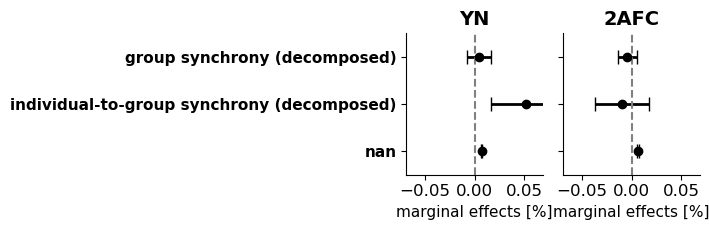

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png


In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Paths
# -------------------------------------------------
yn_path   = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
afc_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"

df_yn   = pd.read_csv(yn_path)
df_2afc = pd.read_csv(afc_path)

# -------------------------------------------------
# Label harmonization (match your OR figure)
# -------------------------------------------------
# If your saved files already contain these labels, this will just keep them consistent.
label_map = {
    "Z1": "group synchrony (decomposed)",
    "Z2": "individual-to-group synchrony (decomposed)"
}

# If your YN/2AFC AME files store Predictor as Z1/Z2, map to paper labels.
if "Predictor" in df_yn.columns:
    df_yn["label_plot"] = df_yn["Predictor"].map(label_map).fillna(df_yn.get("label", df_yn["Predictor"]))
else:
    df_yn["label_plot"] = df_yn["label"]

if "Predictor" in df_2afc.columns:
    df_2afc["label_plot"] = df_2afc["Predictor"].map(label_map).fillna(df_2afc.get("label", df_2afc["Predictor"]))
else:
    df_2afc["label_plot"] = df_2afc["label"]

# Ensure same ordering across panels
order = ["group synchrony (decomposed)", "individual-to-group synchrony (decomposed)"]

df_yn["label_plot"]   = pd.Categorical(df_yn["label_plot"], categories=order,ordered=True)
df_2afc["label_plot"] = pd.Categorical(df_2afc["label_plot"], categories=order, ordered=True)

df_yn   = df_yn.sort_values("label_plot").reset_index(drop=True)
df_2afc = df_2afc.sort_values("label_plot").reset_index(drop=True)



# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, (ax_yn, ax_2afc) = plt.subplots(
    1, 2, figsize=(7.2, 2.4), sharey=True
)

y_pos = np.arange(len(df_yn))

# ---- YN ----
ax_yn.errorbar(
    df_yn["AME"],
    y_pos,
    xerr=[df_yn["AME"] - df_yn["CI_low"],
          df_yn["CI_high"] - df_yn["AME"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_yn.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_yn.set_title("YN", fontsize=14, weight="bold")
ax_yn.set_xlabel("marginal effects [%]", fontsize=11)

# ---- 2AFC ----
ax_2afc.errorbar(
    df_2afc["AME"],
    y_pos,
    xerr=[df_2afc["AME"] - df_2afc["CI_low"],
          df_2afc["CI_high"] - df_2afc["AME"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_2afc.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_2afc.set_title("2AFC", fontsize=14, weight="bold")
ax_2afc.set_xlabel("marginal effects [%]", fontsize=11)


# ---- Shared Y axis labels ----
ax_yn.set_yticks(y_pos)
ax_yn.set_yticklabels(df_yn["label_plot"].astype(str).values, fontsize=11, fontweight="bold")
ax_yn.invert_yaxis()

# ---- Symmetric x-limits around zero (standard for AMEs) ----
xmin = min(-0.05, 0.06)
xmax = max(-0.05, 0.06)
m = max(abs(xmin), abs(xmax)) * 1.15

ax_yn.set_xlim(-m, m)
ax_2afc.set_xlim(-m, m)

# ---- Clean look ----
for ax in (ax_yn, ax_2afc):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax_yn.set_ylim(len(y_pos)- 0.5, - 0.5) # consistent y-limits
   

plt.tight_layout()

# Optional: save
out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_path)


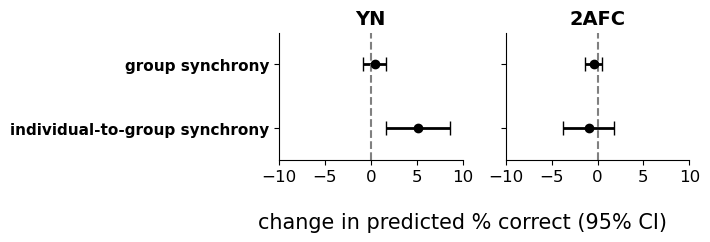

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png


In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# -------------------------------------------------
# Paths
# -------------------------------------------------
yn_path   = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
afc_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"

df_yn   = pd.read_csv(yn_path)
df_2afc = pd.read_csv(afc_path)

df_yn = df_yn[df_yn["Predictor"].isin(["Z1", "Z2"])].copy()
df_2afc = df_2afc[df_2afc["Predictor"].isin(["Z1", "Z2"])].copy()
# -------------------------------------------------
# Label harmonization
# -------------------------------------------------
label_map = {
    "Z1": "group synchrony",
    "Z2": "individual-to-group synchrony"
}

if "Predictor" in df_yn.columns:
    df_yn["label_plot"] = df_yn["Predictor"].map(label_map).fillna(df_yn.get("label", df_yn["Predictor"]))
else:
    df_yn["label_plot"] = df_yn["label"]

if "Predictor" in df_2afc.columns:
    df_2afc["label_plot"] = df_2afc["Predictor"].map(label_map).fillna(df_2afc.get("label", df_2afc["Predictor"]))
else:
    df_2afc["label_plot"] = df_2afc["label"]

order = ["group synchrony", "individual-to-group synchrony"]

df_yn["label_plot"]   = pd.Categorical(df_yn["label_plot"], categories=order, ordered=True)
df_2afc["label_plot"] = pd.Categorical(df_2afc["label_plot"], categories=order, ordered=True)

df_yn   = df_yn.sort_values("label_plot").reset_index(drop=True)
df_2afc = df_2afc.sort_values("label_plot").reset_index(drop=True)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, (ax_yn, ax_2afc) = plt.subplots(1, 2, figsize=(7.2, 2.4), sharey=True)

y_pos = np.arange(len(df_yn))

# Convert to percentage points
for df in (df_yn, df_2afc):
    df["AME_pp"] = df["AME"] *100
    df["CI_low_pp"] = df["CI_low"] *100
    df["CI_high_pp"] = df["CI_high"] *100

# ---- YN ----
ax_yn.errorbar(
    df_yn["AME_pp"],
    y_pos,
    xerr=[df_yn["AME_pp"] - df_yn["CI_low_pp"],
          df_yn["CI_high_pp"] - df_yn["AME_pp"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_yn.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_yn.set_title("YN", fontsize=14, weight="bold")


# ---- 2AFC ----

ax_2afc.errorbar(
    df_2afc["AME_pp"],
    y_pos,
    xerr=[df_2afc["AME_pp"] - df_2afc["CI_low_pp"],
          df_2afc["CI_high_pp"] - df_2afc["AME_pp"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_2afc.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_2afc.set_title("2AFC", fontsize=14, weight="bold")


# ---- Shared Y axis labels ----
ax_yn.set_yticks(y_pos)
ax_yn.set_yticklabels(df_yn["label_plot"].astype(str).values, fontsize=11, fontweight="bold")
ax_yn.invert_yaxis()

# ---- Symmetric x-limits around zero ----
all_vals = np.concatenate([
    df_yn["CI_low_pp"].values, df_yn["CI_high_pp"].values,
    df_2afc["CI_low_pp"].values, df_2afc["CI_high_pp"].values
])

m = np.max(np.abs(all_vals)) * 1.15
for ax in (ax_yn, ax_2afc):
    ax.set_xticks(np.arange(-10, 11, 5))

# ---- Format x-axis as percentages ----
# AME values are probabilities, so 0.05 will display as 5%
for ax in (ax_yn, ax_2afc):
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)

ax_yn.set_ylim(len(y_pos) - 0.5, -0.5)

# title for x-axis

fig.supxlabel("change in predicted % correct (95% CI)", fontsize=15, x = 0.65)

plt.tight_layout()

out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_path)

In [109]:
#model estimates of demposed IGS and GS values

yn_path   = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
afc_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"

df_yn   = pd.read_csv(yn_path)
df_2afc = pd.read_csv(afc_path)

In [111]:
df_2afc

,Predictor,AME,CI_low,CI_high,SE,p_value,label
0,Z1,-0.004079,-0.013475,0.005317,0.004794,0.394856,(individual sync + group sync)/2
1,Z2,-0.009569,-0.037191,0.018052,0.014093,0.497123,(individual sync - group sync)/2


In [ ]:
## for signal present and signal absent AMEs plotting

In [73]:
%%R
library(lme4)

df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_present_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Keep ONLY signal-present trials (hits + misses)
# -------------------------------------------------
df_sp <- droplevels(subset(df, !is.na(signal_present)))

# Verify
cat("N trials:", nrow(df_sp), "\n")
cat("Participants:", length(unique(df_sp$participant_id)), "\n")
table(df_sp$signal_present)

# -------------------------------------------------
# GLMM: detection accuracy on signal-present trials
# -------------------------------------------------
glmm_signal_present <- glmer(
  correct_response_occlusion ~
    pilot_mean +
    group_mean +
    mean_correct_YN_LOO_signal_present +
    (1 | participant_id),
  data = df_sp,
  family = binomial(link = "logit")
)

summary(glmm_signal_present)


N trials: 2922 
Participants: 30 
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
correct_response_occlusion ~ pilot_mean + group_mean + mean_correct_YN_LOO_signal_present +  
    (1 | participant_id)
   Data: df_sp

      AIC       BIC    logLik -2*log(L)  df.resid 
   2092.9    2122.8   -1041.5    2082.9      2917 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.2725  0.2445  0.3160  0.3916  1.5811 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.4345   0.6592  
Number of obs: 2922, groups:  participant_id, 30

Fixed effects:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -0.712259   0.426142  -1.671  0.09464 .  
pilot_mean                          1.091684   0.350032   3.119  0.00182 ** 
group_mean                         -1.117831   0.442358  -2.527  0.01150 *  
mean_correct

In [76]:
df = pd.read_csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv")

In [ ]:
## script for gettig signal-absent trials (I alredy created a file with -aignal-absent trials so I do not need to run it again)

import pandas as pd
import numpy as np

# -------------------------------------------------------------
# 0. Load data
# -------------------------------------------------------------
input_path = (
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/"
    "sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/"
    "30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)

df = pd.read_csv(input_path)
df = df.copy()

print(f"Original data shape: {df.shape}")

# -------------------------------------------------------------
# 1. Identify SIGNAL-ABSENT trials (YN)
# -------------------------------------------------------------
# Signal absent = 1 → Correct Rejection (CR)
# Signal absent = 0 → False Alarm (FA)

df["signal_absent"] = np.where(
    (df["correct_response_occlusion"] == 1) & (df["response_occlusion"] == "right"), 1,
    np.where(
        (df["correct_response_occlusion"] == 0) & (df["response_occlusion"] == "left"), 0,
        np.nan
    )
)

print("\n📊 Signal-absent distribution:")
print(df["signal_absent"].value_counts(dropna=False))

# -------------------------------------------------------------
# 2. Compute LOO accuracy for SIGNAL-ABSENT trials only
# -------------------------------------------------------------
agg_sa = (
    df[df["signal_absent"].notna()]
    .groupby(["movie", "segment_num"], as_index=False)
    .agg(
        sum_CR_SA=("signal_absent", "sum"),   # number of correct rejections
        n_participants_SA=("participant_id", "nunique")
    )
)

df = df.merge(agg_sa, on=["movie", "segment_num"], how="left")

df["mean_correct_YN_LOO_signal_absent"] = np.where(
    (df["n_participants_SA"].notna()) & (df["n_participants_SA"] > 1),
    ((df["sum_CR_SA"] - df["signal_absent"]) /
     (df["n_participants_SA"] - 1)).clip(0, 1),
    np.nan
)

df["mean_correct_YN_LOO_signal_absent"] = df["mean_correct_YN_LOO_signal_absent"] *100
# -------------------------------------------------------------
# 3. Save to NEW file
# -------------------------------------------------------------
out_path = (
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/"
    "sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/"
    "30_subjects_final/all_movies_merged_sync_behav_with_signal_absent_LOO_30_subjects.csv"
)

df.to_csv(out_path, index=False)

print(f"\n✅ File saved to: {out_path}")
print(f"Output data shape: {df.shape}")

# -------------------------------------------------------------
# 4. Quick verification
# -------------------------------------------------------------
print("\n📋 Sample rows:")
print(df[[
    "movie", "segment_num", "participant_id",
    "response_occlusion", "correct_response_occlusion",
    "signal_absent",
    "mean_correct_YN_LOO_signal_absent"
]].head(20))

print("\n Summary:")
print(f"✓ Rows with signal_absent data: {df['signal_absent'].notna().sum()}")
print(f"✓ Correct rejections (signal_absent=1): {(df['signal_absent']==1).sum()}")
print(f"✓ False alarms (signal_absent=0): {(df['signal_absent']==0).sum()}")


In [67]:
%%R
library(lme4)
library(marginaleffects)

df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_present_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Keep ONLY signal-present trials (hits + misses)
# -------------------------------------------------
df_sp <- droplevels(subset(df, !is.na(signal_present)))

# -------------------------
# SANITY CHECKS
# -------------------------
cat("===== Sanity checks: signal-present subset =====\n")
cat("Total rows in full df:", nrow(df), "\n")
cat("Rows in df_sp (signal-present only):", nrow(df_sp), "\n")
cat("Unique participants in df_sp:", length(unique(df_sp$participant_id)), "\n\n")

cat("Distribution of signal_present in df_sp (should be 0/1 only):\n")
print(table(df_sp$signal_present, useNA = "ifany"))
cat("\n")

cat("Response x Correctness in df_sp (hits/misses pattern check):\n")
print(table(df_sp$response_occlusion, df_sp$correct_response_occlusion, useNA="ifany"))
cat("\n")

# -------------------------------------------------
# Scale synchrony predictors (for 1-SD interpretation)
# -------------------------------------------------
df_sp$pilot_mean_z <- as.numeric(scale(df_sp$pilot_mean))
df_sp$group_mean_z <- as.numeric(scale(df_sp$group_mean))

# Optional: if LOO is on 0-100, convert to 0-1
rng <- range(df_sp$mean_correct_YN_LOO_signal_present, na.rm = TRUE)
cat("mean_correct_YN_LOO_signal_present range:", rng[1], "to", rng[2], "\n")



# -------------------------------------------------
# GLMM: detection accuracy on signal-present trials
# -------------------------------------------------
glmm_signal_present <- glmer(
  correct_response_occlusion ~
    pilot_mean_z +
    group_mean_z +
    mean_correct_YN_LOO_signal_present +
    (1 | participant_id),
  data = df_sp,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

cat("===== GLMM summary (signal-present) =====\n")
print(summary(glmm_signal_present))

# -------------------------------------------------
# AME (Average Marginal Effects) on probability scale
# -------------------------------------------------
ame <- avg_slopes(
  glmm_signal_present,
  variables = c("group_mean_z", "pilot_mean_z", "mean_correct_YN_LOO_signal_present"),
  type = "response"
)

ame_df <- as.data.frame(ame)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

label_map <- c(
  group_mean_z = "Group synchrony",
  pilot_mean_z = "Individual-to-group synchrony",
  mean_correct_YN_LOO_signal_present = "Mean correct (YN, signal-present)"
)

out$label_plot <- unname(label_map[out$Predictor])

out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out

===== Sanity checks: signal-present subset =====
Total rows in full df: 6004 
Rows in df_sp (signal-present only): 2922 
Unique participants in df_sp: 30 

Distribution of signal_present in df_sp (should be 0/1 only):

   0    1 
 366 2556 

Response x Correctness in df_sp (hits/misses pattern check):
       
           0    1
  left     0 2556
  right  366    0

mean_correct_YN_LOO_signal_present range: 40 to 100 
===== GLMM summary (signal-present) =====
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
correct_response_occlusion ~ pilot_mean_z + group_mean_z + mean_correct_YN_LOO_signal_present +  
    (1 | participant_id)
   Data: df_sp
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   2092.9    2122.8   -1041.5    2082.9      2917 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.2725  0.2445  0.3160  0.3916  1.5811 

Random effects:
 G

In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [86]:
%%R
library(marginaleffects)


df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_absent_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Keep ONLY signal-absent trials (correct rejections + false alarms)
# -------------------------------------------------
df_signal_absent<- droplevels(subset(df, !is.na(signal_absent)))
# -------------------------------------------------
# Sanity: confirm we are on FA/CR rows only
# -------------------------------------------------
cat("===== Sanity checks: signal-absent subset =====\n")
cat("Rows used:", nrow(df_signal_absent), "\n")
cat("Unique participants:", length(unique(df_signal_absent$participant_id)), "\n\n")

cat("Distribution of signal_absent (should be 0/1 only):\n")
print(table(df_signal_absent$signal_absent, useNA="ifany"))
cat("\n")

cat("Response x Correctness (should reflect CR/FA coding):\n")
print(table(df_signal_absent$response_occlusion, df_signal_absent$correct_response_occlusion, useNA="ifany"))
cat("\n")



# -------------------------------------------------
# Scale synchrony predictors (for 1-SD interpretation)
# -------------------------------------------------
df_signal_absent$pilot_mean_z <- as.numeric(scale(df_signal_absent$pilot_mean))
df_signal_absent$group_mean_z <- as.numeric(scale(df_signal_absent$group_mean))


  # Refit the GLMM on the rescaled covariate (recommended)
  glmm_signal_absent <- glmer(
    correct_response_occlusion ~
      pilot_mean_z +
      group_mean_z +
      mean_correct_YN_LOO_signal_absent +
      (1 | participant_id),
    data = df_signal_absent,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa")
  )


# -------------------------------------------------
# Average Marginal Effects (probability scale, conditional)
# -------------------------------------------------
ame_abs <- avg_slopes(
  glmm_signal_absent,
  variables = c("group_mean_z", "pilot_mean_z", "mean_correct_YN_LOO_signal_absent"),
  type = "response"
)

ame_df <- as.data.frame(ame_abs)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

# Plot labels (group first; matches your desired y-order)
label_map <- c(
  group_mean_z = "Group synchrony",
  pilot_mean_z = "Individual-to-group synchrony",
  mean_correct_YN_LOO_signal_absent = "Mean correct (YN, signal-absent)"
)
out$label_plot <- unname(label_map[out$Predictor])

# Save
out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out


===== Sanity checks: signal-absent subset =====
Rows used: 2992 
Unique participants: 30 

Distribution of signal_absent (should be 0/1 only):

   0    1 
1565 1427 

Response x Correctness (should reflect CR/FA coding):
       
           0    1
  left  1565    0
  right    0 1427


Saved AME table to:
 /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv 

                          Predictor          AME       CI_low     CI_high
1                      group_mean_z -0.019548875 -0.045110041 0.006012290
2 mean_correct_YN_LOO_signal_absent  0.007608464  0.007266540 0.007950388
3                      pilot_mean_z  0.025055713 -0.001041901 0.051153327
            SE   p_value                       label_plot
1 0.0130416507 0.1338848                  Group synchrony
2 0.0001744541 0.0000000 Mean correct (YN, signal-absent)
3 0.0133153538 0.0598746    Individual-to-group synchrony


In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [84]:
%R df_signal_absent

,participant_id,segment_num,pilot_mean,group_mean,correct_response_occlusion,correct_response,response_occlusion,final_choice,target_on_left,occluded_image,...,mean_correct_2AFC_LOO,mean_correct_YN_LOO,signal_present,sum_hits_SP,n_participants_SP,mean_correct_YN_LOO_signal_present,signal_absent,sum_CR_SA,n_participants_SA,mean_correct_YN_LOO_signal_absent
1,7,1,0.320988,0.345468,0,1,no_response,left,True,left,...,79.310345,65.517241,NaN,13.0,13,NaN,NaN,6.0,16,NaN
2,7,2,0.432613,0.567754,1,1,left,left,True,right,...,100.000000,86.206897,1.0,12.0,13,91.666667,NaN,14.0,17,NaN
3,7,3,-0.107644,0.678453,1,1,left,right,False,left,...,89.655172,75.862069,1.0,10.0,13,75.000000,NaN,13.0,17,NaN
4,7,4,-0.089511,0.208065,1,1,left,left,True,right,...,100.000000,86.206897,1.0,15.0,17,87.500000,NaN,11.0,13,NaN
5,7,5,0.535462,0.447035,1,1,right,right,False,right,...,96.551724,75.862069,NaN,13.0,17,NaN,1.0,10.0,12,81.818182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,38,26,0.670101,0.646003,1,1,left,right,False,left,...,100.000000,89.285714,1.0,12.0,13,91.666667,NaN,14.0,15,NaN
6001,38,27,0.497129,0.318337,0,1,right,left,True,right,...,92.857143,75.000000,0.0,11.0,15,78.571429,NaN,10.0,13,NaN
6002,38,28,0.166814,0.178609,1,1,left,right,False,left,...,100.000000,85.714286,1.0,15.0,15,100.000000,NaN,10.0,14,NaN
6003,38,29,0.705142,0.596239,1,1,right,right,False,right,...,100.000000,85.714286,NaN,14.0,17,NaN,1.0,11.0,12,90.909091


In [87]:
import pandas as pd 
import matplotlib.pyplot as plt
present_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv"
absent_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"

df_p = pd.read_csv(present_path)
df_a = pd.read_csv(absent_path)

### doing scaling (z-scoring,so that SD rerpesents 1-unit change); then doing decomposition; then splitting into signal absent trials and doing GLMM

In [100]:
%%R
library(lme4)
library(marginaleffects)

# -------------------------------------------------
# Load full dataset
# -------------------------------------------------
df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_absent_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Decompose synchrony on FULL dataset
# -------------------------------------------------
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))

df$Z1 <- (df$pilot_z + df$group_z) / 2   # shared synchrony
df$Z2 <- (df$pilot_z - df$group_z) / 2   # individual-specific synchrony

# -------------------------------------------------
# Keep ONLY signal-absent trials (CR + FA)
# -------------------------------------------------
df_signal_absent <- droplevels(subset(df, !is.na(signal_absent)))

# -------------------------------------------------
# Sanity checks
# -------------------------------------------------
cat("===== Sanity checks: signal-absent subset =====\n")
cat("Rows used:", nrow(df_signal_absent), "\n")
cat("Unique participants:", length(unique(df_signal_absent$participant_id)), "\n\n")

cat("Distribution of signal_absent (should be 0/1 only):\n")
print(table(df_signal_absent$signal_absent, useNA = "ifany"))
cat("\n")

cat("Response x Correctness (should reflect CR/FA coding):\n")
print(table(df_signal_absent$response_occlusion,
            df_signal_absent$correct_response_occlusion,
            useNA = "ifany"))
cat("\n")

# -------------------------------------------------
# GLMM using decomposed predictors
# -------------------------------------------------
glmm_signal_absent <- glmer(
  correct_response_occlusion ~
    Z1 +
    Z2 +
    mean_correct_YN_LOO_signal_absent +
    (1 | participant_id),
  data = df_signal_absent,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

summary(glmm_signal_absent)

# -------------------------------------------------
# Average Marginal Effects
# -------------------------------------------------
ame_abs <- avg_slopes(
  glmm_signal_absent,
  variables = c("Z1", "Z2", "mean_correct_YN_LOO_signal_absent"),
  type = "response"
)

ame_df <- as.data.frame(ame_abs)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

# -------------------------------------------------
# Labels
# -------------------------------------------------
label_map <- c(
  Z1 = "Group synchrony (decomposed)",
  Z2 = "Individual-to-group synchrony (decomposed)",
  mean_correct_YN_LOO_signal_absent = "Mean correct (YN, signal-absent)"
)

out$label_plot <- unname(label_map[out$Predictor])

# -------------------------------------------------
# Save
# -------------------------------------------------
out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent_decomposed.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out

===== Sanity checks: signal-absent subset =====
Rows used: 2992 
Unique participants: 30 

Distribution of signal_absent (should be 0/1 only):

   0    1 
1565 1427 

Response x Correctness (should reflect CR/FA coding):
       
           0    1
  left  1565    0
  right    0 1427


Saved AME table to:
 /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent_decomposed.csv 

                          Predictor         AME       CI_low    CI_high
1                                Z1 0.005846183 -0.010338088 0.02203045
2                                Z2 0.044730403 -0.004446869 0.09390767
3 mean_correct_YN_LOO_signal_absent 0.007608477  0.007266553 0.00795040
           SE    p_value                                 label_plot
1 0.008257433 0.47895126               Group synchrony (decomposed)
2 0.025090906 0.07462967 Individual-to-group synchrony (decomposed)
3 0.000174454 0.00000000           Mean correct (YN, signal-absent)


In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


### doing scaling and decomposition before splitting into signal present trials and running GLMM


In [101]:
%%R
library(lme4)
library(marginaleffects)

# -------------------------------------------------
# Load full dataset (signal-present version)
# -------------------------------------------------
df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_present_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Decompose synchrony on FULL dataset
# -------------------------------------------------
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))

df$Z1 <- (df$pilot_z + df$group_z) / 2
df$Z2 <- (df$pilot_z - df$group_z) / 2

# -------------------------------------------------
# Keep ONLY signal-present trials (hits + misses)
# -------------------------------------------------
df_signal_present <- droplevels(subset(df, !is.na(signal_present)))

# -------------------------------------------------
# Sanity checks
# -------------------------------------------------
cat("===== Sanity checks: signal-present subset =====\n")
cat("Rows used:", nrow(df_signal_present), "\n")
cat("Unique participants:", length(unique(df_signal_present$participant_id)), "\n\n")

cat("Distribution of signal_present (should be 0/1 only):\n")
print(table(df_signal_present$signal_present, useNA = "ifany"))
cat("\n")

cat("Response x Correctness (should reflect hit/miss coding):\n")
print(table(df_signal_present$response_occlusion,
            df_signal_present$correct_response_occlusion,
            useNA = "ifany"))
cat("\n")

# -------------------------------------------------
# GLMM using decomposed predictors
# -------------------------------------------------
glmm_signal_present <- glmer(
  correct_response_occlusion ~
    Z1 +
    Z2 +
    mean_correct_YN_LOO_signal_present +
    (1 | participant_id),
  data = df_signal_present,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

summary(glmm_signal_present)

# -------------------------------------------------
# Average Marginal Effects
# -------------------------------------------------
ame_abs <- avg_slopes(
  glmm_signal_present,
  variables = c("Z1", "Z2", "mean_correct_YN_LOO_signal_present"),
  type = "response"
)

ame_df <- as.data.frame(ame_abs)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

# -------------------------------------------------
# Labels
# -------------------------------------------------
label_map <- c(
  Z1 = "Group synchrony (decomposed)",
  Z2 = "Individual-to-group synchrony (decomposed)",
  mean_correct_YN_LOO_signal_present = "Mean correct (YN, signal-present)"
)

out$label_plot <- unname(label_map[out$Predictor])

# -------------------------------------------------
# Save
# -------------------------------------------------
out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present_decomposed.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out

===== Sanity checks: signal-present subset =====
Rows used: 2922 
Unique participants: 30 

Distribution of signal_present (should be 0/1 only):

   0    1 
 366 2556 

Response x Correctness (should reflect hit/miss coding):
       
           0    1
  left     0 2556
  right  366    0


Saved AME table to:
 /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present_decomposed.csv 

                           Predictor         AME       CI_low     CI_high
1                                 Z1 0.004821995 -0.007386188 0.017030178
2                                 Z2 0.052041646  0.017087681 0.086995610
3 mean_correct_YN_LOO_signal_present 0.003335000  0.002261767 0.004408234
            SE      p_value                                 label_plot
1 0.0062287792 4.388435e-01               Group synchrony (decomposed)
2 0.0178339831 3.521524e-03 Individual-to-group synchrony (decomposed)
3 0.0005475783 1.125912e-09          Mean correct (YN, 

In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


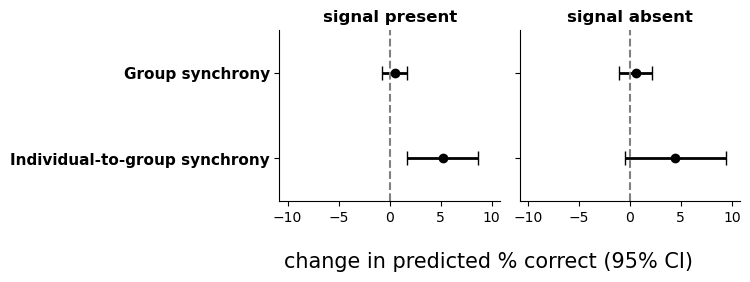

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot_decomposed.png


In [130]:
##plotting signal present and absent marginal effect GLMM results but after decomposotion on all trials

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Paths: decomposed AME results
# -------------------------------------------------
present_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present_decomposed.csv"
absent_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent_decomposed.csv"

# -------------------------------------------------
# Load
# -------------------------------------------------
df_p = pd.read_csv(present_path)
df_a = pd.read_csv(absent_path)

# -------------------------------------------------
# Keep only decomposed synchrony predictors
# -------------------------------------------------
df_p = df_p[df_p["Predictor"].isin(["Z1", "Z2"])].copy()
df_a = df_a[df_a["Predictor"].isin(["Z1", "Z2"])].copy()

# -------------------------------------------------
# Harmonize labels/order
# -------------------------------------------------
# -------------------------------------------------
# Harmonize labels/order
# -------------------------------------------------
label_map = {
    "Z1": "Group synchrony",
    "Z2": "Individual-to-group synchrony"
}

df_p["label_plot"] = df_p["Predictor"].map(label_map)
df_a["label_plot"] = df_a["Predictor"].map(label_map)

order = ["Group synchrony", "Individual-to-group synchrony"]

df_p["label_plot"] = pd.Categorical(df_p["label_plot"], categories=order, ordered=True)
df_a["label_plot"] = pd.Categorical(df_a["label_plot"], categories=order, ordered=True)

df_p = df_p.sort_values("label_plot").reset_index(drop=True)
df_a = df_a.sort_values("label_plot").reset_index(drop=True)

# -------------------------------------------------
# Convert AME + CI to percentage points
# -------------------------------------------------
for df in (df_p, df_a):
    df["AME_pp"] = df["AME"] * 100
    df["CI_low_pp"] = df["CI_low"] * 100
    df["CI_high_pp"] = df["CI_high"] * 100

# -------------------------------------------------
# Plot
# -------------------------------------------------
y_pos = np.arange(len(df_p))
fig, (ax_p, ax_a) = plt.subplots(1, 2, figsize=(7.6, 2.8), sharey=True)

# ---- signal present ----
ax_p.errorbar(
    df_p["AME_pp"],
    y_pos,
    xerr=[
        df_p["AME_pp"] - df_p["CI_low_pp"],
        df_p["CI_high_pp"] - df_p["AME_pp"]
    ],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_p.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_p.set_title("signal present", fontsize=12, weight="bold")


# ---- signal absent ----
ax_a.errorbar(
    df_a["AME_pp"],
    y_pos,
    xerr=[
        df_a["AME_pp"] - df_a["CI_low_pp"],
        df_a["CI_high_pp"] - df_a["AME_pp"]
    ],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_a.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_a.set_title("signal absent", fontsize=12, weight="bold")


# -------------------------------------------------
# -------------------------------------------------
ax_p.set_yticks(y_pos)
ax_p.set_yticklabels(df_p["label_plot"].astype(str).values, fontsize=11, fontweight="bold")
ax_p.invert_yaxis()

# -------------------------------------------------
# Symmetric x-limits across both panels
# -------------------------------------------------
all_vals = np.concatenate([
    df_p["CI_low_pp"].values, df_p["CI_high_pp"].values,
    df_a["CI_low_pp"].values, df_a["CI_high_pp"].values
])

m = np.max(np.abs(all_vals)) * 1.15
ax_p.set_xlim(-m, m)
ax_a.set_xlim(-m, m)


# -------------------------------------------------
# Clean appearance
# -------------------------------------------------
for ax in (ax_p, ax_a):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=10)

ax_p.set_ylim(len(y_pos) - 0.5, -0.5)
# title for x-axis

fig.supxlabel("change in predicted % correct (95% CI)", fontsize=15, x = 0.65)

plt.tight_layout()

# -------------------------------------------------
# Save
# -------------------------------------------------
out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot_decomposed.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


In [106]:
sp = pd.read_csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present_decomposed.csv")
sa = pd.read_csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent_decomposed.csv")

In [ ]:
## plotting AME for signal present and signal absent trials 

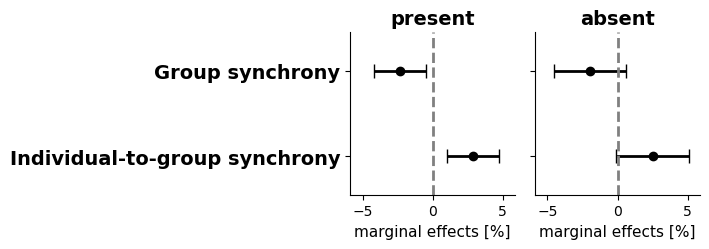

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#removing trial accuracy form the table for plotting in both signal present and signal absent

present_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv"
absent_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"

df_p = pd.read_csv(present_path)
df_a = pd.read_csv(absent_path)
df_p = df_p[df_p["Predictor"].isin(["group_mean_z", "pilot_mean_z"])]
df_a = df_a[df_a["Predictor"].isin(["group_mean_z", "pilot_mean_z"])]

order = ["Group synchrony", "Individual-to-group synchrony"]
df_p["label_plot"] = pd.Categorical(df_p["label_plot"], categories=order, ordered=True)
df_a["label_plot"] = pd.Categorical(df_a["label_plot"], categories=order, ordered=True)

df_p = df_p.sort_values("label_plot").reset_index(drop=True)
df_a = df_a.sort_values("label_plot").reset_index(drop=True)

df_p["AME_pp"] = df_p["AME"] *100
df_p["CI_low"] = df_p["CI_low"] *100
df_p["CI_high"] = df_p["CI_high"] *100

df_a["AME_pp"] = df_a["AME"] *100
df_a["CI_low"] = df_a["CI_low"] *100
df_a["CI_high"] = df_a["CI_high"] *100

y_pos = np.arange(len(df_p))

fig, (ax_p, ax_a) = plt.subplots(1, 2, figsize=(7.2, 2.6), sharey=True)

# present
ax_p.errorbar(
    df_p["AME_pp"], y_pos,
    xerr=[df_p["AME_pp"] - df_p["CI_low"], df_p["CI_high"] - df_p["AME_pp"]],
    fmt="o", color="black", ecolor="black", elinewidth=2, capsize=5, markersize=6
)
ax_p.axvline(0, linestyle="--", color="gray", linewidth=2)
ax_p.set_title("present", fontsize=14, weight="bold")
ax_p.set_xlabel("marginal effects [%]", fontsize=11)

# absent
ax_a.errorbar(
    df_a["AME_pp"], y_pos,
    xerr=[df_a["AME_pp"] - df_a["CI_low"], df_a["CI_high"] - df_a["AME_pp"]],
    fmt="o", color="black", ecolor="black", elinewidth=2, capsize=5, markersize=6
)
ax_a.axvline(0, linestyle="--", color="gray", linewidth=2)
ax_a.set_title("absent", fontsize=14, weight="bold")
ax_a.set_xlabel("marginal effects [%]", fontsize=11)

# y labels
ax_p.set_yticks(y_pos)
ax_p.set_yticklabels(df_p["label_plot"].astype(str).values, fontsize=14, fontweight="bold")
ax_p.invert_yaxis()

# tighten whitespace
ax_p.margins(y=0.03)
ax_a.margins(y=0.03)
ax_p.set_ylim(len(y_pos) - 0.55, -0.45)

# symmetric x limits
xmin = min(df_p["CI_low"].min(), df_a["CI_low"].min())
xmax = max(df_p["CI_high"].max(), df_a["CI_high"].max())
m = max(abs(xmin), abs(xmax)) * 1.15
ax_p.set_xlim(-m, m)
ax_a.set_xlim(-m, m)

for ax in (ax_p, ax_a):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()

out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


In [ ]:
#for signal absent

In [64]:
%%R
library(marginaleffects)

# -------------------------------------------------
# Sanity: confirm we are on FA/CR rows only
# -------------------------------------------------
cat("===== Sanity checks: signal-absent subset =====\n")
cat("Rows used:", nrow(df_signal_absent), "\n")
cat("Unique participants:", length(unique(df_signal_absent$participant_id)), "\n\n")

cat("Distribution of signal_absent (should be 0/1 only):\n")
print(table(df_signal_absent$signal_absent, useNA="ifany"))
cat("\n")

cat("Response x Correctness (should reflect CR/FA coding):\n")
print(table(df_signal_absent$response_occlusion, df_signal_absent$correct_response_occlusion, useNA="ifany"))
cat("\n")

# -------------------------------------------------
# If your LOO was scaled to 0-100, rescale to 0-1
# (recommended for interpretability; does NOT change AME of other predictors)
# -------------------------------------------------
rng <- range(df_signal_absent$mean_correct_YN_LOO_signal_absent, na.rm=TRUE)
cat("mean_correct_YN_LOO_signal_absent range:", rng[1], "to", rng[2], "\n")

if (rng[2] > 1.5) {
  cat("Detected 0-100 scaling; converting mean_correct_YN_LOO_signal_absent back to 0-1.\n\n")
  df_signal_absent$mean_correct_YN_LOO_signal_absent <- df_signal_absent$mean_correct_YN_LOO_signal_absent / 100

  # Refit the GLMM on the rescaled covariate (recommended)
  glmm_signal_absent <- glmer(
    correct_response_occlusion ~
      pilot_mean +
      group_mean +
      mean_correct_YN_LOO_signal_absent +
      (1 | participant_id),
    data = df_signal_absent,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa")
  )
}

# -------------------------------------------------
# Average Marginal Effects (probability scale, conditional)
# -------------------------------------------------
ame_abs <- avg_slopes(
  glmm_signal_absent,
  variables = c("group_mean", "pilot_mean", "mean_correct_YN_LOO_signal_absent"),
  type = "response"
)

ame_df <- as.data.frame(ame_abs)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

# Plot labels (group first; matches your desired y-order)
label_map <- c(
  group_mean = "Group synchrony",
  pilot_mean = "Individual-to-group synchrony",
  mean_correct_YN_LOO_signal_absent = "Mean correct (YN, signal-absent)"
)
out$label_plot <- unname(label_map[out$Predictor])

# Save
#out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"
#write.csv(out, out_path, row.names = FALSE)

#cat("\nSaved AME table to:\n", out_path, "\n\n")
out


===== Sanity checks: signal-absent subset =====
Rows used: 2992 
Unique participants: 30 

Distribution of signal_absent (should be 0/1 only):

   0    1 
1565 1427 

Response x Correctness (should reflect CR/FA coding):
       
           0    1
  left  1565    0
  right    0 1427

mean_correct_YN_LOO_signal_absent range: 0 to 100 
Detected 0-100 scaling; converting mean_correct_YN_LOO_signal_absent back to 0-1.

                          Predictor         AME       CI_low    CI_high
1                        group_mean -0.09456266 -0.218194876 0.02906955
2 mean_correct_YN_LOO_signal_absent  0.76084587  0.726653393 0.79503835
3                        pilot_mean  0.09974387 -0.004139922 0.20362767
          SE   p_value                       label_plot
1 0.06307882 0.1338427                  Group synchrony
2 0.01744546 0.0000000 Mean correct (YN, signal-absent)
3 0.05300291 0.0598555    Individual-to-group synchrony


In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [65]:
%%R
library(dplyr)
library(ggplot2)
library(marginaleffects)
library(patchwork)

# Assumes you already have:
#   df_signal_absent
#   glmm_signal_absent
# And you potentially rescaled mean_correct_YN_LOO_signal_absent to 0-1 (as in your script)

# ----------------------------
# Helper: prediction grid (population-level)
# ----------------------------
make_grid_abs <- function(df_abs, xvar, n = 200) {
  x_seq <- seq(
    quantile(df_abs[[xvar]], 0.01, na.rm = TRUE),
    quantile(df_abs[[xvar]], 0.99, na.rm = TRUE),
    length.out = n
  )

  newdata <- data.frame(
    pilot_mean                        = mean(df_abs$pilot_mean, na.rm = TRUE),
    group_mean                        = mean(df_abs$group_mean, na.rm = TRUE),
    mean_correct_YN_LOO_signal_absent  = mean(df_abs$mean_correct_YN_LOO_signal_absent, na.rm = TRUE),
    participant_id                    = df_abs$participant_id[1],  # required by (1|participant_id)
    stringsAsFactors = FALSE
  )

  newdata <- newdata[rep(1, length(x_seq)), ]
  newdata[[xvar]] <- x_seq
  newdata
}

# ----------------------------
# Model predictions (IGS & GS)
# ----------------------------
new_igs <- make_grid_abs(df_signal_absent, "pilot_mean", n = 200)
pred_igs_df <- as.data.frame(
  predictions(glmm_signal_absent, newdata = new_igs, type = "response", re.form = NA)
)

new_gs <- make_grid_abs(df_signal_absent, "group_mean", n = 200)
pred_gs_df <- as.data.frame(
  predictions(glmm_signal_absent, newdata = new_gs, type = "response", re.form = NA)
)

# ----------------------------
# Spaghetti raw summaries (bins within participant)
# ----------------------------
nbins <- 10

spaghetti_igs <- df_signal_absent %>%
  group_by(participant_id) %>%
  mutate(bin = ntile(pilot_mean, nbins)) %>%
  group_by(participant_id, bin) %>%
  summarise(
    x = mean(pilot_mean, na.rm = TRUE),
    y = mean(correct_response_occlusion, na.rm = TRUE),
    .groups = "drop"
  )

spaghetti_gs <- df_signal_absent %>%
  group_by(participant_id) %>%
  mutate(bin = ntile(group_mean, nbins)) %>%
  group_by(participant_id, bin) %>%
  summarise(
    x = mean(group_mean, na.rm = TRUE),
    y = mean(correct_response_occlusion, na.rm = TRUE),
    .groups = "drop"
  )

# ----------------------------
# Plot styling
# ----------------------------
base_theme <- theme_classic(base_size = 14) +
  theme(
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.text.x  = element_text(size = 14),
    axis.text.y  = element_text(size = 14),
    plot.title   = element_blank()
  )

# ----------------------------
# IGS panel (signal-absent)
# ----------------------------
p_igs_abs <- ggplot() +
  geom_ribbon(
    data = pred_igs_df,
    aes(x = pilot_mean, ymin = conf.low, ymax = conf.high),
    alpha = 0.20
  ) +
  geom_line(
    data = pred_igs_df,
    aes(x = pilot_mean, y = estimate),
    linewidth = 1.3
  ) +
  geom_line(
    data = spaghetti_igs,
    aes(x = x, y = y, group = participant_id),
    alpha = 0.25,
    linewidth = 0.6
  ) +
  labs(
    x = "Individual-to-group synchrony (IGS)",
    y = "P(correct) (signal-absent)"
  ) +
  coord_cartesian(ylim = c(0, 1)) +
  base_theme

# ----------------------------
# GS panel (signal-absent)
# ----------------------------
p_gs_abs <- ggplot() +
  geom_ribbon(
    data = pred_gs_df,
    aes(x = group_mean, ymin = conf.low, ymax = conf.high),
    alpha = 0.20
  ) +
  geom_line(
    data = pred_gs_df,
    aes(x = group_mean, y = estimate),
    linewidth = 1.3
  ) +
  geom_line(
    data = spaghetti_gs,
    aes(x = x, y = y, group = participant_id),
    alpha = 0.25,
    linewidth = 0.6
  ) +
  labs(
    x = "Group synchrony (GS)",
    y = "P(correct) (signal-absent)"
  ) +
  coord_cartesian(ylim = c(0, 1)) +
  base_theme

# ----------------------------
# Combine and save
# ----------------------------
both_abs <- p_igs_abs + p_gs_abs + plot_layout(ncol = 2)

OUT_ABS <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_predprob_spaghetti_signal_absent_IGS_GS.png"
ggsave(OUT_ABS, both_abs, width = 10.2, height = 3.6, dpi = 300)

both_abs
OUT_ABS

[1] "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_predprob_spaghetti_signal_absent_IGS_GS.png"


In [66]:
%%R
library(patchwork)

combined <- both_sp / both_abs  # top row = signal-present, bottom row = signal-absent

OUT_COMBINED <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_predprob_spaghetti_signal_present_vs_absent.png"
ggsave(OUT_COMBINED, combined, width = 10.2, height = 7.4, dpi = 300)

combined
OUT_COMBINED

[1] "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_predprob_spaghetti_signal_present_vs_absent.png"
